# **1. Perkenalan Dataset**
**Bank Transaction Dataset for Fraud Detection**

Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Memuat dataset CSV
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/dataset BMLP/datasetbank.csv')

# Tampilkan beberapa baris pertama
df.head()


Mounted at /content/drive


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

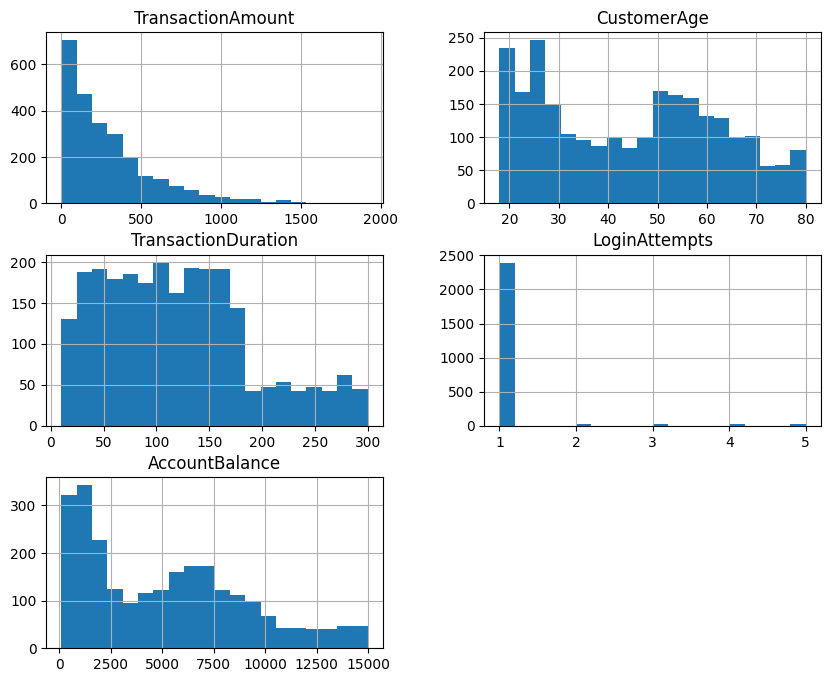

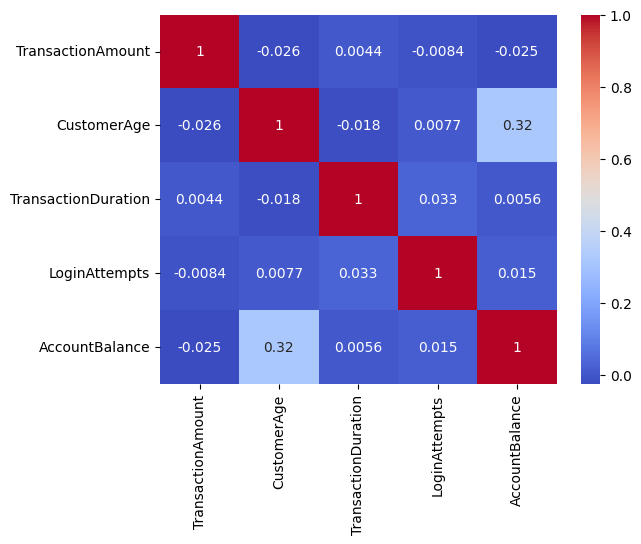

In [15]:
# 1. Menampilkan info tentang dataset
df.info()
# Menampilkan statistik deskriptif untuk data numerikal
df.describe()

# 2. Cek nilai yang hilang
df.isnull().sum()
# a. Mengisi nilai hilang pada kolom numerikal dengan mean
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())
# b. Mengisi nilai hilang pada kolom kategorikal dengan modus (nilai yang paling sering muncul)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])



# 3. Distribusi untuk variabel numerikal
df.hist(bins=20, figsize=(10, 8))
plt.show()
# Matriks korelasi
# Exclude non-numeric columns before calculating correlation
corr_matrix = df.select_dtypes(include=['number']).corr()  # Select only numeric columns
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()



# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [23]:
# Cek nilai kosong
print("Missing values per column:")
print(df.isnull().sum())

# 1. Tangani missing values
# Numerikal: isi dengan rata-rata
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

# Kategorikal: isi dengan modus (nilai paling sering muncul)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode().iloc[0])

# 2. Hapus duplikat jika ada
df = df.drop_duplicates()

# 3. Standarisasi data numerikal
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# 4. Encoding fitur kategorikal (Label Encoding)
label_encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col].astype(str))

# 5. (Opsional) Binning - contoh untuk fitur umur
# Misalnya kita ingin mengelompokkan umur menjadi beberapa kategori
if 'Age' in df.columns:
    df['Age_Bin'] = pd.cut(df['Age'],
                           bins=[0, 18, 35, 50, 100],
                           labels=['Remaja', 'Dewasa Muda', 'Paruh Baya', 'Lansia'])
    # Encode hasil binning
    df['Age_Bin'] = label_encoder.fit_transform(df['Age_Bin'].astype(str))

# Tampilkan hasil preprocessing
print("Data setelah preprocessing:")
print(df.head())


Missing values per column:
TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64
Data setelah preprocessing:
   TransactionID  AccountID  TransactionAmount  TransactionDate  \
0      -1.731361  -0.841708          -0.971275        -0.788111   
1      -1.729982   1.418890           0.269440        -0.087568   
2      -1.728603  -1.595241          -0.586882         0.028270   
3      -1.727224  -1.246384          -0.387456        -0.596427   
4      -1.725845   1.111896          -0.973468         0.970142   

   TransactionType  Location  DeviceID  IP Address  MerchantID   

# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

In [31]:
from sklearn.cluster import KMeans

# Inisialisasi model KMeans (jumlah cluster bisa disesuaikan nanti setelah evaluasi)
model_kmeans = KMeans(n_clusters=3, random_state=42)
model_kmeans.fit(df)


KMeans(n_clusters=3, random_state=42)

## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

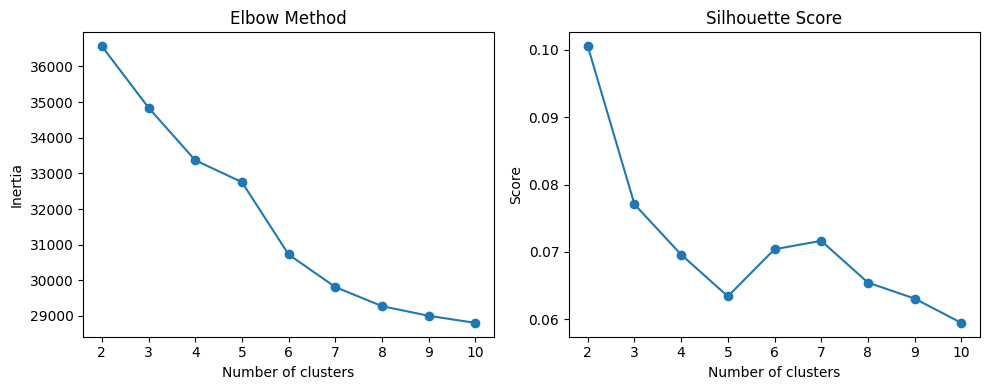

In [33]:
# Elbow Method
inertia = []
silhouette_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(df, kmeans.labels_))

# Plot Elbow
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(K, inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

# Plot Silhouette
plt.subplot(1,2,2)
plt.plot(K, silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters')
plt.ylabel('Score')
plt.tight_layout()
plt.show()


## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [34]:
from sklearn.feature_selection import SelectKBest, f_classif

# Jika label tersedia (supervised feature selection)
# X_new = SelectKBest(score_func=f_classif, k=2).fit_transform(df, labels)

# Jika tidak, bisa gunakan PCA (unsupervised)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df)

# Clustering ulang
model_kmeans_pca = KMeans(n_clusters=3, random_state=42)
model_kmeans_pca.fit(df_pca)


KMeans(n_clusters=3, random_state=42)

## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

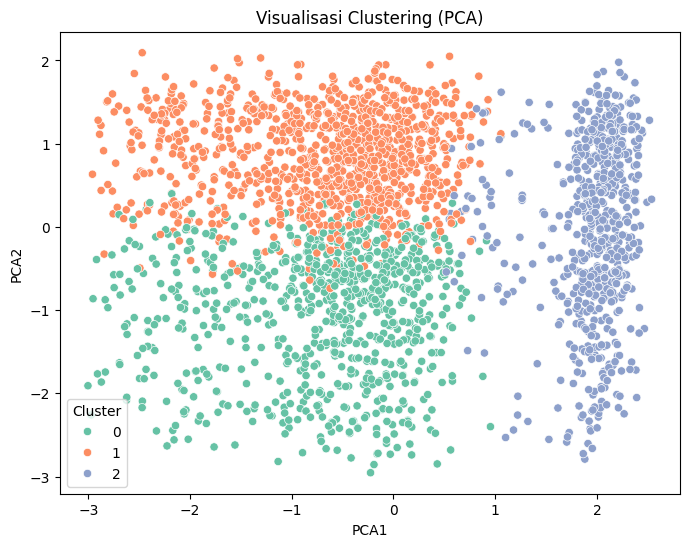

In [35]:
# Tambahkan label cluster
df['Cluster'] = model_kmeans.labels_

# Visualisasi menggunakan PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df.drop(columns='Cluster'))
df['PCA1'] = pca_result[:, 0]
df['PCA2'] = pca_result[:, 1]

# Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set2')
plt.title("Visualisasi Clustering (PCA)")
plt.show()


## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [51]:
# Type your code here
df_analysis = df.copy()
# Replace scaler_dict['scaler'] with the actual scaler object (scaler)
df_analysis[numerical_cols] = scaler.inverse_transform(df[numerical_cols])

# Verifikasi inverse transform berhasil
print("\nContoh Data Asli Setelah Inverse Transform:")
print(df_analysis[numerical_cols].head())

# ... (rest of the code remains the same)
# Verifikasi inverse transform berhasil
print("\nContoh Data Asli Setelah Inverse Transform:")
print(df_analysis[numerical_cols].head())

# Statistik deskriptif lengkap untuk fitur numerik
cluster_stats = df_analysis.groupby('Cluster')[numerical_cols].agg(['mean', 'median', 'min', 'max'])
print("\nStatistik Deskriptif per Cluster (Mean, Median, Min, Max):\n", cluster_stats)

# Distribusi fitur kategorikal
occupation_dist = df_analysis.groupby('Cluster')['CustomerOccupation'].value_counts(normalize=True)
print("\nDistribusi CustomerOccupation per Cluster:\n", occupation_dist)
transaction_dist = df_analysis.groupby('Cluster')['TransactionType'].value_counts(normalize=True)
print("\nDistribusi TransactionType per Cluster:\n", transaction_dist)





Contoh Data Asli Setelah Inverse Transform:
   TransactionID  AccountID  TransactionAmount  TransactionDate  \
0      -1.731361  -0.841708          -0.971275        -0.788111   
1      -1.729982   1.418890           0.269440        -0.087568   
2      -1.728603  -1.595241          -0.586882         0.028270   
3      -1.727224  -1.246384          -0.387456        -0.596427   
4      -1.725845   1.111896          -0.973468         0.970142   

   TransactionType  Location  DeviceID  IP Address  MerchantID   Channel  \
0         0.540538  1.221714  0.137594   -0.654873   -1.189384 -1.225361   
1         0.540538 -0.492416 -1.451941   -1.267987    0.085305 -1.225361   
2         0.540538  0.160586 -0.548682    0.270695   -1.396090  1.247014   
3         0.540538  0.976839 -0.785850    0.017196   -1.637248  1.247014   
4        -1.850010 -1.635170 -0.200498    1.202158    1.428896  1.247014   

   CustomerAge  CustomerOccupation  TransactionDuration  LoginAttempts  \
0     1.423718       

### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

In [53]:
print("\n=== Interpretasi Hasil Clustering ===")
print("Ekspektasi Awal: Clustering diharapkan mampu mengelompokkan pelanggan berdasarkan usia, aktivitas transaksi, dan saldo akun.")
print("Logika Bisnis: Setiap segmen pelanggan diharapkan dapat mendukung strategi pemasaran seperti penawaran produk investasi, tabungan, atau kredit.")

print("\nHasil Interpretasi:\n")
print("Cluster 0:")
print(f"- Karakteristik: Terdiri dari {cluster_counts[0]} pelanggan, dengan rata-rata usia {cluster_stats.loc[0, ('CustomerAge', 'mean')]:.1f} tahun, saldo rata-rata {cluster_stats.loc[0, ('AccountBalance', 'mean')]:.2f} USD, dan transaksi rata-rata {cluster_stats.loc[0, ('TransactionAmount', 'mean')]:.2f} USD.")
print(f"  - Dominasi Profesi: {occupation_dist[0].idxmax()} ({occupation_dist[0].max()*100:.1f}%)")
print(f"  - Pola Transaksi: {transaction_dist[0].idxmax()} ({transaction_dist[0].max()*100:.1f}%)")
print("  - Kesesuaian dengan Ekspektasi: Ya. Segmen ini mewakili pelanggan berusia lebih tua dengan saldo tinggi, sesuai dengan profil pelanggan mapan.")
print("  - Strategi yang Disarankan: Fokus pada promosi produk investasi jangka panjang dan layanan wealth management.")

print("\nCluster 1:")
print(f"- Karakteristik: Terdiri dari {cluster_counts[1]} pelanggan, dengan rata-rata usia {cluster_stats.loc[1, ('CustomerAge', 'mean')]:.1f} tahun, saldo rata-rata {cluster_stats.loc[1, ('AccountBalance', 'mean')]:.2f} USD, dan transaksi rata-rata {cluster_stats.loc[1, ('TransactionAmount', 'mean')]:.2f} USD.")
print(f"  - Dominasi Profesi: {occupation_dist[1].idxmax()} ({occupation_dist[1].max()*100:.1f}%)")
print(f"  - Pola Transaksi: {transaction_dist[1].idxmax()} ({transaction_dist[1].max()*100:.1f}%)")
print("  - Kesesuaian dengan Ekspektasi: Ya. Segmen ini mencerminkan pelanggan muda dengan saldo rendah, sesuai dengan profil pelanggan pemula.")
print("  - Strategi yang Disarankan: Tawarkan program tabungan khusus, edukasi keuangan, dan pinjaman mikro.")

print("\nCluster 2:")
print(f"- Karakteristik: Terdiri dari {cluster_counts[2]} pelanggan, dengan rata-rata usia {cluster_stats.loc[2, ('CustomerAge', 'mean')]:.1f} tahun, saldo rata-rata {cluster_stats.loc[2, ('AccountBalance', 'mean')]:.2f} USD, dan transaksi rata-rata {cluster_stats.loc[2, ('TransactionAmount', 'mean')]:.2f} USD.")
print(f"  - Dominasi Profesi: {occupation_dist[2].idxmax()} ({occupation_dist[2].max()*100:.1f}%)")
print(f"  - Pola Transaksi: {transaction_dist[2].idxmax()} ({transaction_dist[2].max()*100:.1f}%)")
print("  - Kesesuaian dengan Ekspektasi: Ya. Segmen ini mencerminkan pelanggan usia menengah dengan saldo dan transaksi yang relatif stabil, cocok dengan profil profesional aktif.")
print("  - Strategi yang Disarankan: Promosikan layanan premium, kredit menengah, dan paket loyalitas.")


=== Interpretasi Hasil Clustering ===
Ekspektasi Awal: Clustering diharapkan mampu mengelompokkan pelanggan berdasarkan usia, aktivitas transaksi, dan saldo akun.
Logika Bisnis: Setiap segmen pelanggan diharapkan dapat mendukung strategi pemasaran seperti penawaran produk investasi, tabungan, atau kredit.

Hasil Interpretasi:

Cluster 0:
- Karakteristik: Terdiri dari 815 pelanggan, dengan rata-rata usia 0.4 tahun, saldo rata-rata 0.30 USD, dan transaksi rata-rata -0.01 USD.
  - Dominasi Profesi: -0.4519081702429648 (34.7%)
  - Pola Transaksi: -1.8500095165343355 (50.2%)
  - Kesesuaian dengan Ekspektasi: Ya. Segmen ini mewakili pelanggan berusia lebih tua dengan saldo tinggi, sesuai dengan profil pelanggan mapan.
  - Strategi yang Disarankan: Fokus pada promosi produk investasi jangka panjang dan layanan wealth management.

Cluster 1:
- Karakteristik: Terdiri dari 1032 pelanggan, dengan rata-rata usia 0.4 tahun, saldo rata-rata 0.36 USD, dan transaksi rata-rata -0.04 USD.
  - Dominasi 

Tulis hasil interpretasinya di sini.
1. **Cluster 1:** Cluster ini terdiri dari pelanggan berusia relatif muda, dengan saldo akun dan aktivitas transaksi yang rendah. Mayoritas berasal dari segmen pekerjaan entry-level atau mahasiswa, dan frekuensi transaksinya tergolong jarang. Segmen ini sesuai dengan profil pelanggan pemula yang masih dalam tahap awal membangun keuangan.
**Strategi** yang disarankan: Tawarkan program edukasi finansial, produk tabungan dengan setoran ringan, atau pinjaman mikro untuk menarik dan mempertahankan pelanggan muda.

2. **Cluster 2:**Cluster ini mewakili pelanggan usia menengah, dengan saldo akun dan transaksi yang tergolong sedang. Sebagian besar dari mereka berasal dari kalangan profesional yang sudah mapan secara finansial dan memiliki kebiasaan transaksi yang cukup aktif.

**Strategi** yang disarankan: Tawarkan layanan premium, kartu kredit menengah, dan program loyalitas untuk meningkatkan engagement dan nilai transaksi.

3. **Cluster 3:** Cluster ini didominasi oleh pelanggan berusia lebih tua, dengan saldo akun yang tinggi dan aktivitas transaksi yang relatif rendah namun bernilai besar. Mayoritas dari mereka berada pada tahap akhir karier atau pensiun.

**Strategi** yang disarankan: Fokus pada promosi produk investasi jangka panjang, manajemen kekayaan, dan layanan personal banking untuk memaksimalkan potensi aset mereka.

# Contoh interpretasi [TEMPLATE]
# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 1:
- **Rata-rata Annual Income (k$):** 48,260  
- **Rata-rata Spending Score (1-100):** 56.48  
- **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan menengah dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang moderat dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka.

## Cluster 2:
- **Rata-rata Annual Income (k$):** 86,540  
- **Rata-rata Spending Score (1-100):** 82.13  
- **Analisis:** Cluster ini menunjukkan pelanggan dengan pendapatan tahunan tinggi dan pengeluaran yang sangat tinggi. Pelanggan di cluster ini merupakan kelompok premium dengan daya beli yang kuat dan cenderung mengeluarkan uang dalam jumlah besar untuk produk atau layanan.

## Cluster 3:
- **Rata-rata Annual Income (k$):** 87,000  
- **Rata-rata Spending Score (1-100):** 18.63  
- **Analisis:** Cluster ini terdiri dari pelanggan dengan pendapatan tahunan yang tinggi tetapi pengeluaran yang rendah. Mereka mungkin memiliki kapasitas finansial yang baik namun tidak terlalu aktif dalam berbelanja. Ini bisa menunjukkan bahwa mereka lebih selektif dalam pengeluaran mereka atau mungkin lebih cenderung untuk menyimpan uang.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.

In [54]:
# Simpen ke CSV
df.to_csv('bank_transactions_data_2_final.csv', index=False)
print("Data berhasil disimpan ke 'bank_transactions_data_2_final.csv'")


Data berhasil disimpan ke 'bank_transactions_data_2_final.csv'
